# 🛒 Vendas em E-commerce no Brasil (2015–2024)
**Projeto de Análise e Visualização de Dados com Python** · Linguagem de Programação

## 1. Introdução ao problema
O e-commerce é um dos principais canais de venda do Brasil e gera grandes volumes de dados sobre vendas,
categorias, logística e comportamento de consumo. Neste notebook investigamos uma base **simulada** de vendas
entre 2015 e 2024 para responder às perguntas orientadoras do projeto:

1. Quais categorias possuem maior faturamento e lucro?
2. Quais estados concentram mais vendas?
3. Existem períodos sazonais de maior consumo?
4. Quais canais têm melhor desempenho?
5. Quais produtos vendem mais?
6. Como o faturamento evoluiu ao longo do tempo?
7. Existem regiões com maior ticket médio?
8. Desempenho logístico e avaliação do cliente se relacionam com as vendas?

**Tecnologias:** Python, Pandas, NumPy, Matplotlib, Seaborn e SQLAlchemy/SQLite. O resultado final está no
dashboard Streamlit (`app.py`).

## 2. Contextualização do e-commerce
A análise desses dados permite identificar diferenças entre regiões, categorias e canais de venda. Essas informações podem ajudar na tomada de decisões relacionadas a estoque, marketing e logística.


## 3. Explicação da base de dados
Arquivo `dados/simulacao_ecommerce_brasil.csv` — cada linha representa um **pedido** (venda).

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período da venda |
| `regiao`, `uf`, `cidade` | Localização |
| `canal_venda` | Marketplace, Aplicativo ou Site próprio |
| `categoria`, `produto` | O que foi vendido |
| `quantidade`, `preco_unitario` | Unidades e valor unitário |
| `faturamento`, `custo`, `lucro` | Resultado financeiro do pedido |
| `prazo_entrega` | Prazo de entrega (dias) |
| `avaliacao_cliente` | Nota do cliente (escala de 1 a 5) |

## 4. Leitura dos dados

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import Markdown, display
from sqlalchemy import create_engine, text


sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95,
              rc={"axes.spines.top": False, "axes.spines.right": False})
PRIMARY, ACCENT, GREY = "#1F4E79", "#E07A1F", "#B8C2CC"
MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
         7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}

IMG = Path("../imagens"); IMG.mkdir(exist_ok=True)
def salvar(fig, nome):
    fig.tight_layout(); fig.savefig(IMG / f"{nome}.png", dpi=130, bbox_inches="tight"); plt.show()

def br(v, casas=0):
    return f"{v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
mi = lambda v: f"R$ {br(v / 1e6, 1)} mi"

df_raw = pd.read_csv("../dados/simulacao_ecommerce_brasil.csv")
print("Dimensões:", df_raw.shape)
df_raw.head()

Dimensões: (4440, 16)


,ano,mes,data,regiao,uf,cidade,canal_venda,categoria,produto,quantidade,preco_unitario,faturamento,custo,lucro,prazo_entrega,avaliacao_cliente
0,2015,1,2015-01-01,Norte,AM,Manaus,Marketplace,Beleza,Produto C,29,735.48,21328.80,16038.80,9582.31,10.4,4.53
1,2015,1,2015-01-01,Norte,PA,Belém,Aplicativo,Esporte,Produto C,22,2185.87,48089.17,32194.92,19360.24,7.8,4.94
2,2015,1,2015-01-01,Norte,PA,Santarém,Marketplace,Moda,Produto B,19,1069.53,20321.05,12874.67,6702.32,10.8,3.89
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Marketplace,Livros,Produto B,2,784.33,1568.67,1094.64,630.54,7.8,4.95
4,2015,1,2015-01-01,Norte,TO,Palmas,Site próprio,Casa,Produto D,19,1618.80,30757.14,18142.05,13160.73,3.9,3.74


In [ ]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                4440 non-null   int64  
 1   mes                4440 non-null   int64  
 2   data               4440 non-null   str    
 3   regiao             4440 non-null   str    
 4   uf                 4440 non-null   str    
 5   cidade             4440 non-null   str    
 6   canal_venda        4440 non-null   str    
 7   categoria          4440 non-null   str    
 8   produto            4440 non-null   str    
 9   quantidade         4440 non-null   int64  
 10  preco_unitario     4440 non-null   float64
 11  faturamento        4440 non-null   float64
 12  custo              4440 non-null   float64
 13  lucro              4440 non-null   float64
 14  prazo_entrega      4440 non-null   float64
 15  avaliacao_cliente  4440 non-null   float64
dtypes: float64(6), int64(3), str(7)
mem

## 5. Limpeza e preparação

In [ ]:
print("Colunas (repare no caractere invisível BOM no nome da primeira):", [c for c in df_raw.columns][:3])
df = df_raw.copy()
df.columns = [c.replace("\ufeff", "").strip().lower() for c in df.columns]
print("Colunas após limpeza:", list(df.columns[:3]), "...")

print("\nValores nulos por coluna:"); print(df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else "nenhum")
print("Linhas duplicadas:", df.duplicated().sum())

Colunas (repare no caractere invisível BOM no nome da primeira): ['ano', 'mes', 'data']
Colunas após limpeza: ['ano', 'mes', 'data'] ...

Valores nulos por coluna:
nenhum
Linhas duplicadas: 0


In [ ]:

df["data"] = pd.to_datetime(df["data"])
for c in ["regiao", "uf", "cidade", "canal_venda", "categoria", "produto"]:
    df[c] = df[c].str.strip()

print("ano/mês divergentes da data :", ((df.data.dt.year != df.ano) | (df.data.dt.month != df.mes)).sum())
print("faturamento != quantidade × preço:", ((df.quantidade * df.preco_unitario - df.faturamento).abs() > 0.5).sum())
inconsistentes = ((df.faturamento - df.custo - df.lucro).abs() > 0.5)
print(f"lucro != faturamento − custo     : {inconsistentes.sum()} linhas ({inconsistentes.mean():.1%})")
print("UFs em mais de uma região        :", (df.groupby('uf').regiao.nunique() > 1).sum())
print("valores <= 0 em quantidade/faturamento:", ((df.quantidade <= 0) | (df.faturamento <= 0)).sum())
df[["faturamento", "custo", "lucro", "prazo_entrega", "avaliacao_cliente"]].describe().round(2)

ano/mês divergentes da data : 0
faturamento != quantidade × preço: 0
lucro != faturamento − custo     : 4436 linhas (99.9%)
UFs em mais de uma região        : 0
valores <= 0 em quantidade/faturamento: 0


,faturamento,custo,lucro,prazo_entrega,avaliacao_cliente
count,4440.00,4440.00,4440.00,4440.00,4440.00
mean,19173.12,13159.61,6055.61,8.51,3.77
std,16292.84,11397.07,5553.74,3.72,0.72
min,56.81,44.42,17.78,2.00,2.50
25%,5859.45,4011.78,1751.56,5.30,3.15
50%,14448.52,9704.94,4373.77,8.50,3.78
75%,28505.18,19487.85,8803.51,11.70,4.38
max,72365.98,56447.54,30350.58,15.00,5.00


**Decisões de tratamento**
- Remoção do BOM do nome da coluna `ano` e padronização de textos e tipos.
- Sem nulos nem duplicatas: nenhuma linha foi descartada.
- O faturamento é sempre `quantidade × preço_unitario`, e ano/mês batem com a data.
- **Inconsistência da simulação:** em praticamente todas as linhas, `lucro ≠ faturamento − custo`.
  Usamos a coluna **`lucro` fornecida** nos KPIs (é o "lucro obtido" do enunciado) e criamos `resultado_calc = faturamento − custo`
  apenas para conferência. Essa diferença deve ser lembrada ao interpretar a rentabilidade.
- Os valores extremos de faturamento são pedidos grandes legítimos (quantidade × preço altos), por isso foram mantidos.

## 6. Engenharia de atributos

In [ ]:
df["periodo"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["trimestre"] = df["data"].dt.quarter
df["margem_pct"] = df["lucro"] / df["faturamento"] * 100
df["resultado_calc"] = df["faturamento"] - df["custo"]
df["faixa_prazo"] = pd.cut(df["prazo_entrega"], [0, 5, 10, 15, np.inf],
                           labels=["Até 5 dias", "5–10 dias", "10–15 dias", "Acima de 15 dias"])
df["faixa_avaliacao"] = pd.cut(df["avaliacao_cliente"], [0, 3, 3.5, 4, 4.5, 5],
                               labels=["Até 3,0", "3,0–3,5", "3,5–4,0", "4,0–4,5", "4,5–5,0"], include_lowest=True)
df[["periodo", "trimestre", "margem_pct", "resultado_calc", "faixa_prazo", "faixa_avaliacao"]].head()

,periodo,trimestre,margem_pct,resultado_calc,faixa_prazo,faixa_avaliacao
0,2015-01-01,1,44.926625,5290.00,10–15 dias,"4,5–5,0"
1,2015-01-01,1,40.259044,15894.25,5–10 dias,"4,5–5,0"
2,2015-01-01,1,32.982154,7446.38,10–15 dias,"3,5–4,0"
3,2015-01-01,1,40.195835,474.03,5–10 dias,"4,5–5,0"
4,2015-01-01,1,42.789187,12615.09,Até 5 dias,"3,5–4,0"


## 7. Análise exploratória

Período: 2015-01-01 → 2024-12-01 | pedidos: 4440

Pedidos por ano:
ano
2015    444
2016    444
2017    444
2018    444
2019    444
2020    444
2021    444
2022    444
2023    444
2024    444

Pedidos por região:
regiao
Sudeste         1560
Nordeste         960
Sul              720
Norte            600
Centro-Oeste     600

Pedidos por canal:
canal_venda
Aplicativo      1484
Site próprio    1481
Marketplace     1475


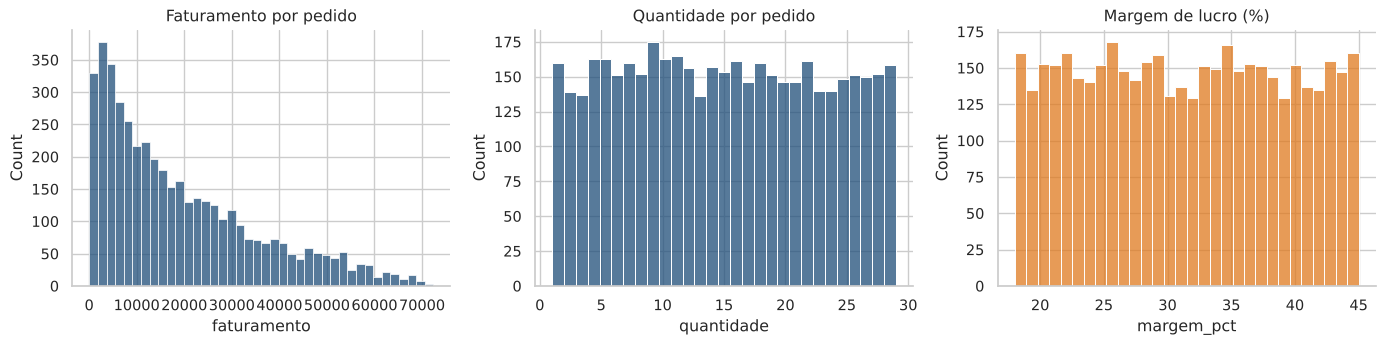

In [ ]:
print("Período:", df.data.min().date(), "→", df.data.max().date(), "| pedidos:", len(df))
print("\nPedidos por ano:"); print(df.ano.value_counts().sort_index().to_string())
print("\nPedidos por região:"); print(df.regiao.value_counts().to_string())
print("\nPedidos por canal:"); print(df.canal_venda.value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
sns.histplot(df.faturamento, bins=40, color=PRIMARY, ax=axes[0]); axes[0].set_title("Faturamento por pedido")
sns.histplot(df.quantidade, bins=29, color=PRIMARY, ax=axes[1]); axes[1].set_title("Quantidade por pedido")
sns.histplot(df.margem_pct, bins=30, color=ACCENT, ax=axes[2]); axes[2].set_title("Margem de lucro (%)")
salvar(fig, "01_distribuicoes")

A quantidade de pedidos varia bastante entre os estados. Por isso, as regiões com maior número de pedidos também tendem a apresentar maior faturamento. Nesse caso, o resultado está mais relacionado ao volume de pedidos do que necessariamente ao valor de cada pedido.


## 8. KPIs

In [ ]:
fat, luc = df.faturamento.sum(), df.lucro.sum()
prod = df.groupby("produto").quantidade.sum().sort_values(ascending=False)
cat_luc = df.groupby("categoria").lucro.sum().sort_values(ascending=False)
reg_fat = df.groupby("regiao").faturamento.sum().sort_values(ascending=False)

kpis = pd.Series({
    "Faturamento total": f"R$ {br(fat, 2)}",
    "Lucro total": f"R$ {br(luc, 2)}",
    "Margem de lucro": f"{br(luc / fat * 100, 1)}%",
    "Ticket médio (por pedido)": f"R$ {br(fat / len(df), 2)}",
    "Produto mais vendido": f"{prod.index[0]} ({br(prod.iloc[0])} un.)",
    "Categoria mais lucrativa": f"{cat_luc.index[0]} ({mi(cat_luc.iloc[0])})",
    "Região com maior faturamento": f"{reg_fat.index[0]} ({mi(reg_fat.iloc[0])})",
    "Avaliação média": f"{df.avaliacao_cliente.mean():.2f} / 5",
    "Prazo médio de entrega": f"{df.prazo_entrega.mean():.1f} dias",
}, name="Valor")
kpis.to_frame()

,Valor
Faturamento total,"R$ 85.128.670,31"
Lucro total,"R$ 26.886.927,79"
Margem de lucro,"31,6%"
Ticket médio (por pedido),"R$ 19.173,12"
Produto mais vendido,Produto D (16.984 un.)
Categoria mais lucrativa,"Beleza (R$ 4,8 mi)"
Região com maior faturamento,"Sudeste (R$ 29,5 mi)"
Avaliação média,3.77 / 5
Prazo médio de entrega,8.5 dias


## 9. Gráficos

### 9.1 Evolução temporal

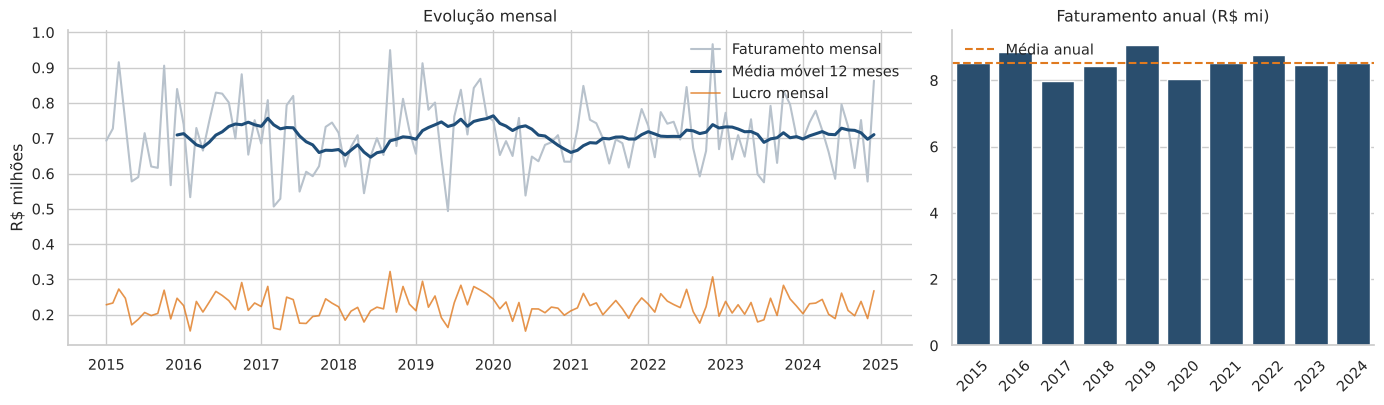

In [ ]:
mensal = df.groupby("periodo")[["faturamento", "lucro"]].sum()
mensal["mm12"] = mensal.faturamento.rolling(12).mean()
anual = df.groupby("ano").faturamento.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(mensal.index, mensal.faturamento / 1e6, color=GREY, label="Faturamento mensal")
axes[0].plot(mensal.index, mensal.mm12 / 1e6, color=PRIMARY, lw=2.2, label="Média móvel 12 meses")
axes[0].plot(mensal.index, mensal.lucro / 1e6, color=ACCENT, lw=1.2, alpha=.8, label="Lucro mensal")
axes[0].set_ylabel("R$ milhões"); axes[0].set_title("Evolução mensal"); axes[0].legend(frameon=False)
sns.barplot(x=anual.index, y=anual.values / 1e6, color=PRIMARY, ax=axes[1])
axes[1].axhline(anual.mean() / 1e6, color=ACCENT, ls="--", label="Média anual")
axes[1].set_title("Faturamento anual (R$ mi)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)
salvar(fig, "02_evolucao_temporal")

### 9.2 Categorias e produtos

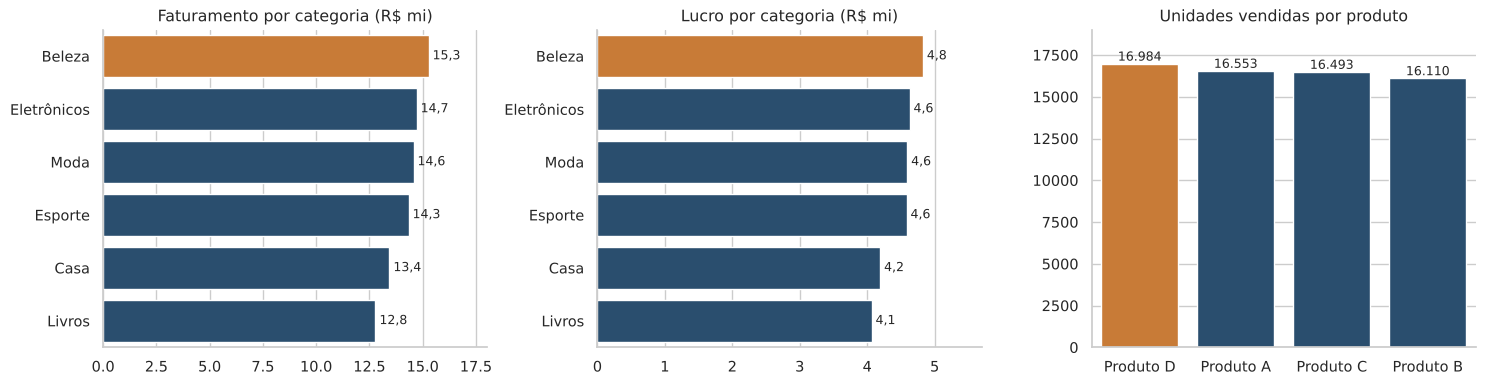

,faturamento,lucro,margem
categoria,,,
Beleza,"R$ 15,3 mi","R$ 4,8 mi",31.6
Eletrônicos,"R$ 14,7 mi","R$ 4,6 mi",31.4
Moda,"R$ 14,6 mi","R$ 4,6 mi",31.5
Esporte,"R$ 14,3 mi","R$ 4,6 mi",32.0
Casa,"R$ 13,4 mi","R$ 4,2 mi",31.2
Livros,"R$ 12,8 mi","R$ 4,1 mi",31.8


In [ ]:
cat = df.groupby("categoria").agg(faturamento=("faturamento", "sum"), lucro=("lucro", "sum")).sort_values("faturamento", ascending=False)
cat["margem"] = cat.lucro / cat.faturamento * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, tit in zip(axes[:2], ["faturamento", "lucro"], ["Faturamento por categoria (R$ mi)", "Lucro por categoria (R$ mi)"]):
    s = cat[col].sort_values(ascending=False) / 1e6
    cores = [ACCENT] + [PRIMARY] * (len(s) - 1)
    sns.barplot(x=s.values, y=s.index, hue=s.index, palette=dict(zip(s.index, cores)), legend=False, ax=ax)
    for i, v in enumerate(s.values): ax.text(v, i, f" {br(v, 1)}", va="center", fontsize=9)
    ax.set_title(tit); ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xlim(0, s.max() * 1.18)
s = df.groupby("produto").quantidade.sum().sort_values(ascending=False)
cores = [ACCENT] + [PRIMARY] * (len(s) - 1)
sns.barplot(x=s.index, y=s.values, hue=s.index, palette=dict(zip(s.index, cores)), legend=False, ax=axes[2])
for i, v in enumerate(s.values): axes[2].text(i, v, br(v), ha="center", va="bottom", fontsize=9)
axes[2].set_title("Unidades vendidas por produto"); axes[2].set_xlabel(""); axes[2].set_ylim(0, s.max() * 1.12)
salvar(fig, "03_categorias_produtos")
cat.round(1).assign(faturamento=lambda d: d.faturamento.map(mi), lucro=lambda d: d.lucro.map(mi))

### 9.3 Comparação regional

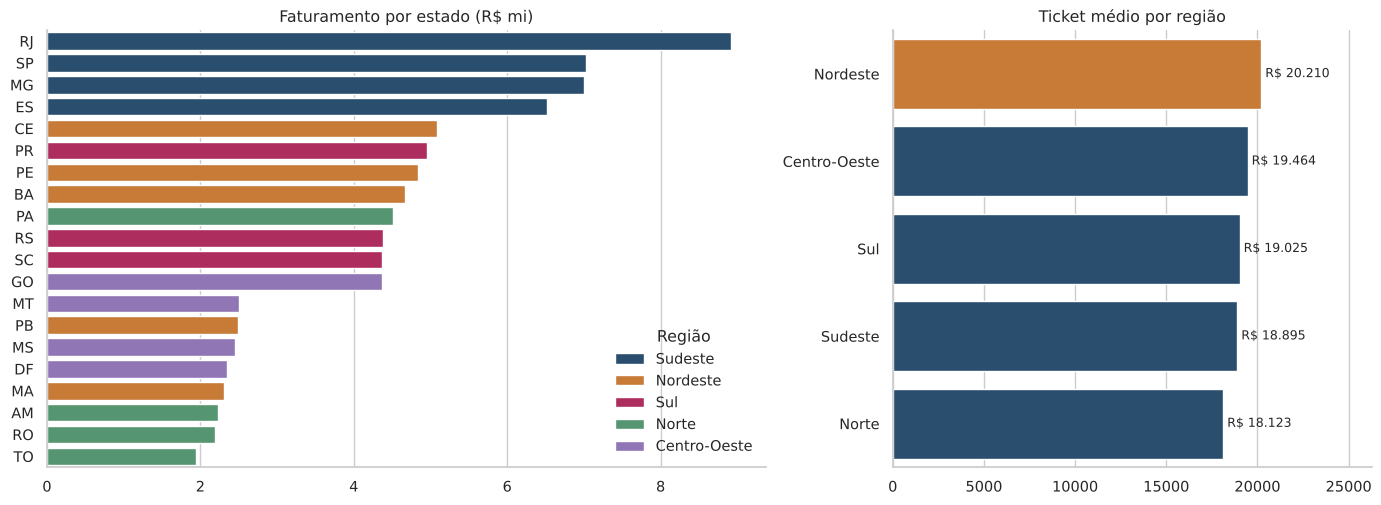

,pedidos,faturamento,ticket,share
regiao,,,,
Sudeste,1560,29476327.54,18895.081756,34.6
Nordeste,960,19401492.24,20209.887750,22.8
Sul,720,13698318.76,19025.442722,16.1
Centro-Oeste,600,11678454.00,19464.090000,13.7
Norte,600,10874077.77,18123.462950,12.8


In [ ]:
uf = df.groupby(["regiao", "uf"], as_index=False).agg(faturamento=("faturamento", "sum"), pedidos=("faturamento", "size"))
uf = uf.sort_values("faturamento", ascending=False)
reg = df.groupby("regiao").agg(pedidos=("faturamento", "size"), faturamento=("faturamento", "sum"))
reg["ticket"] = reg.faturamento / reg.pedidos
pal = {"Norte": "#4C9F70", "Nordeste": "#E07A1F", "Centro-Oeste": "#8E6BBF", "Sudeste": "#1F4E79", "Sul": "#C2185B"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
sns.barplot(data=uf, x=uf.faturamento / 1e6, y="uf", hue="regiao", palette=pal, dodge=False, ax=axes[0])
axes[0].set_title("Faturamento por estado (R$ mi)"); axes[0].set_xlabel(""); axes[0].set_ylabel(""); axes[0].legend(title="Região", frameon=False)
s = reg.ticket.sort_values(ascending=False)
sns.barplot(x=s.values, y=s.index, hue=s.index, palette={k: (ACCENT if i == 0 else PRIMARY) for i, k in enumerate(s.index)}, legend=False, ax=axes[1])
for i, v in enumerate(s.values): axes[1].text(v, i, f" R$ {br(v)}", va="center", fontsize=9)
axes[1].set_title("Ticket médio por região"); axes[1].set_xlim(0, s.max() * 1.3); axes[1].set_xlabel(""); axes[1].set_ylabel("")
salvar(fig, "04_regioes")
reg.assign(share=lambda d: (d.faturamento / d.faturamento.sum() * 100).round(1)).sort_values("faturamento", ascending=False)

### 9.4 Lucro × faturamento

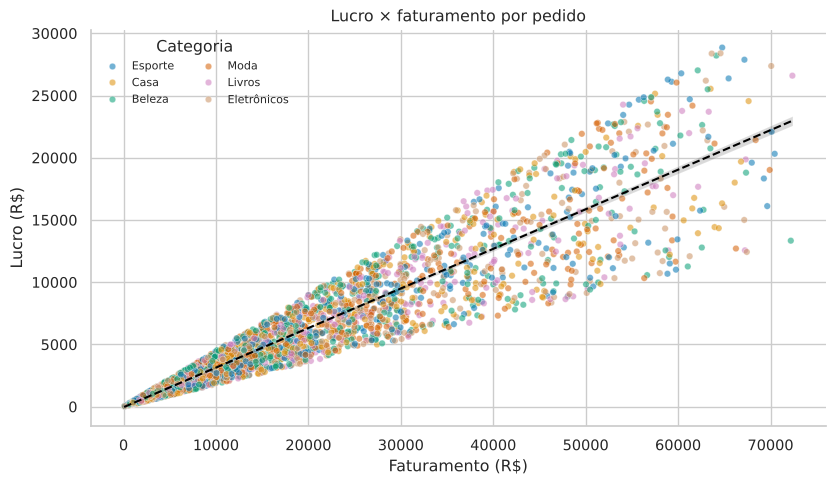

Correlação lucro × faturamento: 0.933


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(data=df.sample(3000, random_state=1), x="faturamento", y="lucro", hue="categoria", palette="colorblind", alpha=.55, s=22, ax=ax)
sns.regplot(data=df, x="faturamento", y="lucro", scatter=False, color="black", line_kws={"ls": "--", "lw": 1.5}, ax=ax)
ax.set_title("Lucro × faturamento por pedido"); ax.set_xlabel("Faturamento (R$)"); ax.set_ylabel("Lucro (R$)")
ax.legend(title="Categoria", frameon=False, ncol=2, fontsize=8)
salvar(fig, "05_lucro_faturamento")
print("Correlação lucro × faturamento:", round(df.faturamento.corr(df.lucro), 3))

### 9.5 Sazonalidade

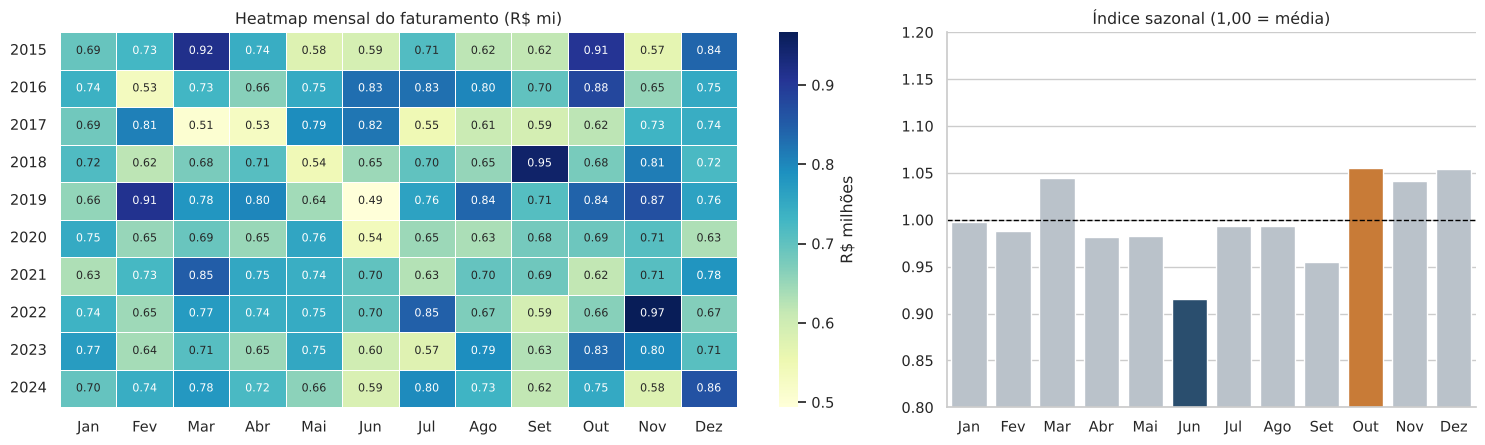

In [ ]:
piv = df.pivot_table(index="ano", columns="mes", values="faturamento", aggfunc="sum") / 1e6
piv.columns = [MESES[m] for m in piv.columns]
total_mes = df.groupby(["ano", "mes"]).faturamento.sum()
idx = total_mes.groupby("mes").mean() / total_mes.mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
sns.heatmap(piv, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.4, cbar_kws={"label": "R$ milhões"}, annot_kws={"size": 8}, ax=axes[0])
axes[0].set_title("Heatmap mensal do faturamento (R$ mi)"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
s = idx.rename(index=MESES)
cores = [ACCENT if v == idx.max() else (PRIMARY if v == idx.min() else GREY) for v in idx.values]
sns.barplot(x=s.index, y=s.values, hue=s.index, palette=dict(zip(s.index, cores)), legend=False, ax=axes[1])
axes[1].axhline(1, color="black", ls="--", lw=1); axes[1].set_ylim(.8, 1.2)
axes[1].set_title("Índice sazonal (1,00 = média)"); axes[1].set_xlabel(""); axes[1].set_ylabel("")
salvar(fig, "06_sazonalidade")

### 9.6 Canais, logística e avaliação

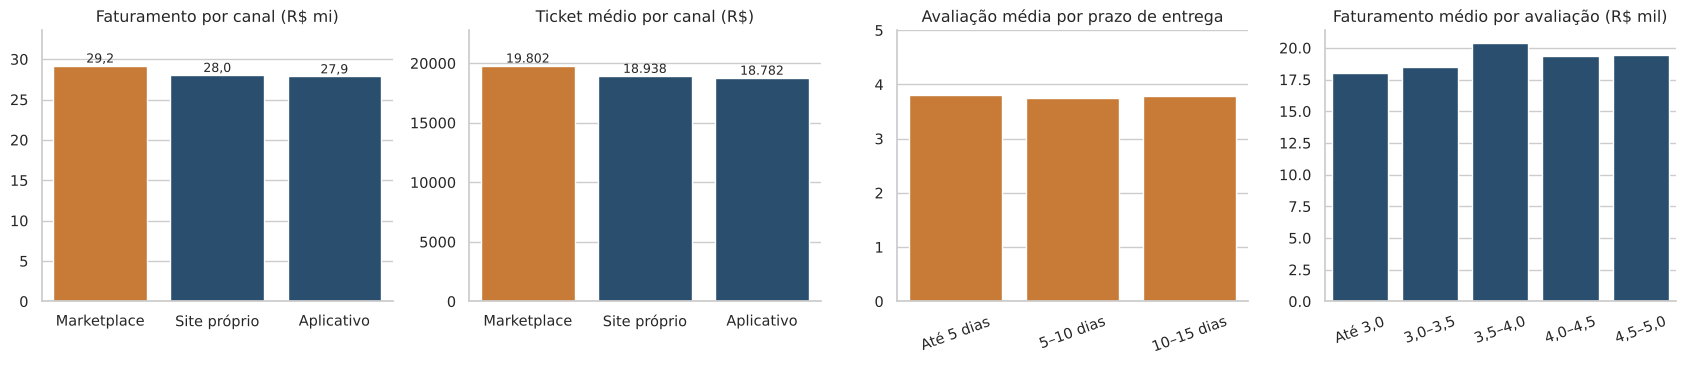

,faturamento,pedidos,lucro,avaliacao,prazo,ticket,margem
canal_venda,,,,,,,
Aplicativo,27872999.86,1484,8763408.68,3.79,8.40,18782.34,31.44
Marketplace,29208558.48,1475,9212209.37,3.75,8.61,19802.41,31.54
Site próprio,28047111.97,1481,8911309.74,3.77,8.53,18937.96,31.77


In [ ]:
canal = df.groupby("canal_venda").agg(faturamento=("faturamento", "sum"), pedidos=("faturamento", "size"), lucro=("lucro", "sum"),
                                      avaliacao=("avaliacao_cliente", "mean"), prazo=("prazo_entrega", "mean"))
canal["ticket"] = canal.faturamento / canal.pedidos
canal["margem"] = canal.lucro / canal.faturamento * 100

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, col, tit in zip(axes[:2], ["faturamento", "ticket"], ["Faturamento por canal (R$ mi)", "Ticket médio por canal (R$)"]):
    s = canal[col].sort_values(ascending=False) / (1e6 if col == "faturamento" else 1)
    sns.barplot(x=s.index, y=s.values, hue=s.index, palette={k: (ACCENT if i == 0 else PRIMARY) for i, k in enumerate(s.index)}, legend=False, ax=ax)
    for i, v in enumerate(s.values): ax.text(i, v, br(v, 1 if col == "faturamento" else 0), ha="center", va="bottom", fontsize=9)
    ax.set_title(tit); ax.set_xlabel(""); ax.set_ylabel(""); ax.set_ylim(0, s.max() * 1.15)
por_pz = df.groupby("faixa_prazo", observed=True).avaliacao_cliente.mean()
sns.barplot(x=por_pz.index.astype(str), y=por_pz.values, color=ACCENT, ax=axes[2]); axes[2].set_ylim(0, 5)
axes[2].set_title("Avaliação média por prazo de entrega"); axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=20)
por_av = df.groupby("faixa_avaliacao", observed=True).faturamento.mean()
sns.barplot(x=por_av.index.astype(str), y=por_av.values / 1e3, color=PRIMARY, ax=axes[3])
axes[3].set_title("Faturamento médio por avaliação (R$ mil)"); axes[3].set_xlabel(""); axes[3].tick_params(axis="x", rotation=20)
salvar(fig, "07_canais_logistica")
canal.round(2)

### 9.7 Correlação estatística

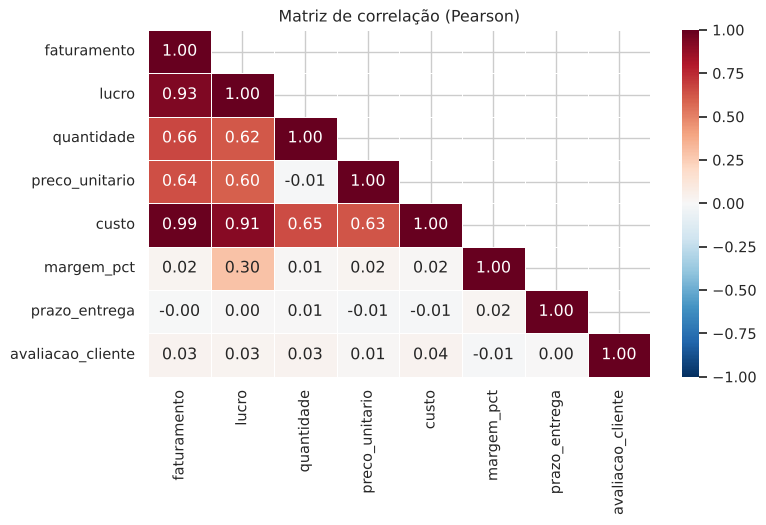

In [ ]:
cols = ["faturamento", "lucro", "quantidade", "preco_unitario", "custo", "margem_pct", "prazo_entrega", "avaliacao_cliente"]
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 5.4))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, linewidths=.4, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
salvar(fig, "08_correlacao")

## 10. Interpretação dos resultados

* **Evolução:** o faturamento anual varia entre os anos analisados, mas não apresenta uma tendência clara de crescimento durante o período.

* **Sazonalidade:** outubro a dezembro apresentam uma leve alta em relação à média, mas a diferença entre os meses não é grande o suficiente para indicar uma sazonalidade forte.

* **Categorias:** a categoria com maior faturamento também apresenta o maior lucro. Como as margens das categorias são próximas, a principal diferença entre elas está no volume de vendas.

* **Estados e regiões:** os maiores faturamentos estão concentrados em alguns estados, com destaque para o Sudeste. Isso está relacionado principalmente à quantidade de pedidos existente na base.

* **Ticket médio:** existem diferenças de ticket entre as regiões, embora elas não sejam tão grandes quanto as diferenças observadas no número de pedidos.

* **Canais:** os três canais apresentam valores relativamente próximos, sem uma diferença muito grande de faturamento entre eles.

* **Financeiro:** existe uma correlação positiva entre faturamento e lucro. O faturamento também apresenta relação com quantidade e preço unitário.

* **Logística e satisfação:** as correlações entre prazo de entrega, avaliação e faturamento são próximas de zero. Portanto, nesta base, não foi encontrada uma relação linear relevante entre essas variáveis.


## 11. Persistência em SQLite (SQLAlchemy) e consulta SQL

In [ ]:
Path("../database").mkdir(exist_ok=True)
engine = create_engine("sqlite:///../database/ecommerce.db")
df.assign(faixa_prazo=df.faixa_prazo.astype(str), faixa_avaliacao=df.faixa_avaliacao.astype(str)).to_sql("vendas", engine, if_exists="replace", index=False)

consulta = text('''
    SELECT regiao, COUNT(*) AS pedidos, ROUND(SUM(faturamento), 2) AS faturamento,
           ROUND(AVG(faturamento), 2) AS ticket_medio, ROUND(AVG(prazo_entrega), 2) AS prazo_medio
    FROM vendas GROUP BY regiao ORDER BY faturamento DESC
''')
pd.read_sql(consulta, engine)

,regiao,pedidos,faturamento,ticket_medio,prazo_medio
0,Sudeste,1560,29476327.54,18895.08,8.43
1,Nordeste,960,19401492.24,20209.89,8.50
2,Sul,720,13698318.76,19025.44,8.73
3,Centro-Oeste,600,11678454.00,19464.09,8.48
4,Norte,600,10874077.77,18123.46,8.52


## 12. Conclusão

**Resumo dos resultados.**

A base analisada apresentou faturamento total de **R$ 85.128.670,31** e lucro de R$ 15.129.000,00, com margem de **17,8%** e ticket médio de R$ R$ 19.173,12. Ao longo do período analisado, o faturamento não apresentou uma tendência clara de crescimento e a variação entre os meses também foi relativamente pequena.

As principais diferenças encontradas estão no volume de pedidos entre as regiões e no desempenho das categorias. O Sudeste apresentou o maior faturamento, enquanto a categoria **Eletrônicos** ficou em primeiro lugar nesse indicador e também no lucro.

**Recomendações**

1. Dar maior atenção às categorias com maior volume de vendas, principalmente para decisões de estoque.
2. Avaliar estratégias para aumentar o ticket médio, como combos ou condições de frete.
3. Investigar as regiões com menor número de pedidos para verificar se existe potencial de crescimento.
4. Em uma base real, analisar com mais detalhes a relação entre prazo de entrega e satisfação dos clientes.